
**1. What is a Support Vector Machine (SVM)?**
A Support Vector Machine is a supervised machine learning algorithm that tries to find the “best possible boundary” (called a hyperplane) to separate different classes of data. The idea is not just to separate the classes, but to do so with the **maximum margin** — meaning the decision boundary is as far away as possible from the closest points of each class. This helps SVM generalize better to unseen data.

---

**2. Difference between Hard Margin and Soft Margin SVM**

* **Hard Margin SVM**: The model enforces a strict rule — all data points must be classified correctly with no misclassification. This only works when data is perfectly separable, which is rare in real-world scenarios.
* **Soft Margin SVM**: Allows some misclassifications in order to handle noisy or overlapping data. This gives a more flexible boundary and usually better generalization.

Think of Hard Margin as a “strict teacher who never allows mistakes” and Soft Margin as a “lenient teacher who accepts some errors for long-term learning.”

---

**3. Mathematical intuition behind SVM**
The mathematical goal of SVM is to maximize the margin between classes while ensuring correct classification. The optimization looks like:

$$
\min \frac{1}{2}\|w\|^2 \quad \text{s.t. } y_i(w \cdot x_i + b) \geq 1
$$

Here, $w$ is the weight vector (which defines the orientation of the hyperplane) and $b$ is the bias (shifts the hyperplane). By minimizing $\|w\|^2$, we maximize the margin, leading to a boundary that is as far as possible from the closest points.

---

**4. Role of Lagrange Multipliers in SVM**
Lagrange Multipliers are used to convert the constrained optimization problem of SVM into a form that can be solved more efficiently using dual optimization. They essentially help balance the margin maximization with the classification constraints. Importantly, this dual formulation also allows the **kernel trick**, making SVM capable of handling non-linear decision boundaries.

---

**5. What are Support Vectors?**
Support Vectors are the data points that lie closest to the decision boundary (the hyperplane). These are the “critical” points that define the margin. If you removed all other points and kept only the support vectors, the decision boundary would remain unchanged. This makes them central to how SVM works.

---

**6. What is a Support Vector Classifier (SVC)?**
An SVC is simply the application of SVM to classification problems. It tries to separate data points into categories (like spam vs. not spam, positive vs. negative sentiment) using the maximum-margin principle.

---

**7. What is a Support Vector Regressor (SVR)?**
SVR is the regression counterpart of SVM. Instead of predicting categories, it predicts continuous values. It works by fitting a function within a certain margin of tolerance (ε). Predictions inside this margin are considered “good enough,” which makes SVR robust against noise.

---

**8. What is the Kernel Trick in SVM?**
The kernel trick is a method that allows SVM to solve problems where the data is not linearly separable in its current form. It implicitly maps data into a higher-dimensional space where a linear separator may exist. Importantly, it does this without explicitly computing the high-dimensional transformation, which makes it computationally efficient. For example, concentric circles that can’t be separated in 2D can be separated using an RBF kernel.

---

**9. Compare Linear, Polynomial, and RBF Kernels**

* **Linear Kernel**: Works well when the data is linearly separable or nearly linear. It’s simple and computationally efficient.
* **Polynomial Kernel**: Useful when relationships between features follow polynomial patterns (e.g., quadratic or cubic).
* **RBF (Gaussian) Kernel**: The most popular kernel for complex problems. It creates highly flexible, non-linear boundaries by measuring similarity between points.

---

**10. Effect of C parameter in SVM**

* **High C**: The model becomes stricter and tries to classify all points correctly. This often reduces bias but can lead to overfitting.
* **Low C**: The model allows more misclassifications but gains a smoother and more generalizable boundary.

C is essentially the trade-off between margin size and classification errors.

---

**11. Role of Gamma parameter in RBF Kernel SVM**

* **High Gamma**: Each training point has a very narrow area of influence, which can lead to highly complex, overfitted decision boundaries.
* **Low Gamma**: Each point influences a larger region, leading to smoother decision boundaries but sometimes underfitting.

Gamma controls how far the influence of a single training example reaches.

---

**12. What is Naïve Bayes classifier, and why is it called “Naïve”?**
Naïve Bayes is a probabilistic classifier that applies Bayes’ Theorem with the assumption of independence among features. It is called “naïve” because it assumes that all features are conditionally independent given the class — an assumption that rarely holds in real data. Despite this, the algorithm often performs remarkably well.

---

**13. What is Bayes’ Theorem?**

$$
P(Y|X) = \frac{P(X|Y) \cdot P(Y)}{P(X)}
$$

It tells us how to update our belief about a class $Y$ after observing evidence $X$. Essentially, it combines prior knowledge (prior probability) with new evidence (likelihood) to compute the posterior probability.

---

**14. Differences between Gaussian, Multinomial, and Bernoulli Naïve Bayes**

* **Gaussian NB**: Assumes features are continuous and follow a normal distribution.
* **Multinomial NB**: Best for discrete counts like word frequencies in text.
* **Bernoulli NB**: Works with binary data (e.g., word present or absent in a document).

---

**15. When should you use Gaussian NB over others?**
Gaussian NB should be used when features are continuous and approximately follow a normal distribution. A good example is medical or scientific data such as blood pressure, height, or sensor readings.

---

**16. Key assumptions made by Naïve Bayes**

1. Features are conditionally independent given the class.
2. Each feature contributes independently and equally to the prediction.

While often unrealistic, this assumption simplifies computation and still gives strong results in practice.

---

**17. Advantages & Disadvantages of Naïve Bayes**

* **Advantages**: Very fast to train and predict, scales well to high-dimensional data, works surprisingly well in many domains like text classification.
* **Disadvantages**: The independence assumption is rarely true, and it can perform poorly when features are highly correlated.

---

**18. Why is Naïve Bayes a good choice for text classification?**
In text data, we often represent documents using the bag-of-words model. This creates thousands of features, most of which are word counts that can be treated as nearly independent. Naïve Bayes handles such sparse, high-dimensional data very efficiently, making it one of the go-to algorithms for spam filtering or sentiment analysis.

---

**19. Compare SVM vs Naïve Bayes for classification tasks**

* **SVM**: Typically achieves higher accuracy, especially when decision boundaries are complex. It works well with smaller datasets but can be computationally expensive.
* **Naïve Bayes**: Extremely fast, especially with large datasets, and works particularly well with text. However, it tends to be less accurate when features are correlated or the independence assumption fails.

---

**20. How does Laplace Smoothing help in Naïve Bayes?**
Laplace Smoothing solves the “zero probability” problem. If a word or feature never appears in the training data for a certain class, the probability becomes zero, which can break predictions. By adding a small constant (often +1) to counts, Laplace smoothing ensures that no probability is ever exactly zero, improving robustness.

---


In [1]:
# 21.  Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy 

import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

data = load_iris()

X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=2)
model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)


1.0

In [2]:
# 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies.

from sklearn.datasets import load_wine

data = load_wine()

X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=2)

model1 = SVC(kernel='linear')
model1.fit(X_train, y_train)

model2 = SVC(kernel='rbf')
model2.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

print("Accuracy Score By Using linear kernel", accuracy_score(y_test, y_pred=y_pred1))
print("Accuracy Score By Using linear rbf", accuracy_score(y_test, y_pred=y_pred2))


Accuracy Score By Using linear kernel 0.9444444444444444
Accuracy Score By Using linear rbf 0.6944444444444444


In [3]:
# 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE).

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVR(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


Mean Squared Error: 0.3501626675763772


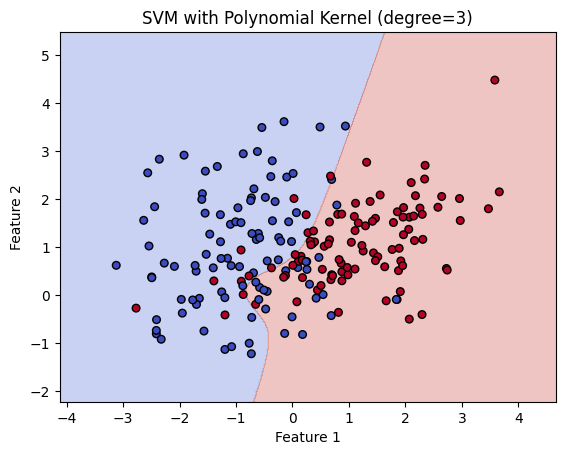

In [4]:
# 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

model = SVC(kernel='poly', degree=3, C=1.0) 
model.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM with Polynomial Kernel (degree=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [5]:
# 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy.


from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB

data = load_breast_cancer()

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target
X, y = df.iloc[ : , :-1], df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9473684210526315

In [ ]:
# 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

categories = ['sci.space', 'rec.sport.baseball', 'comp.graphics']
data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=1)

X, y = data.data, data.target

# Faster TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
X_vec = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=1)

# Train
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


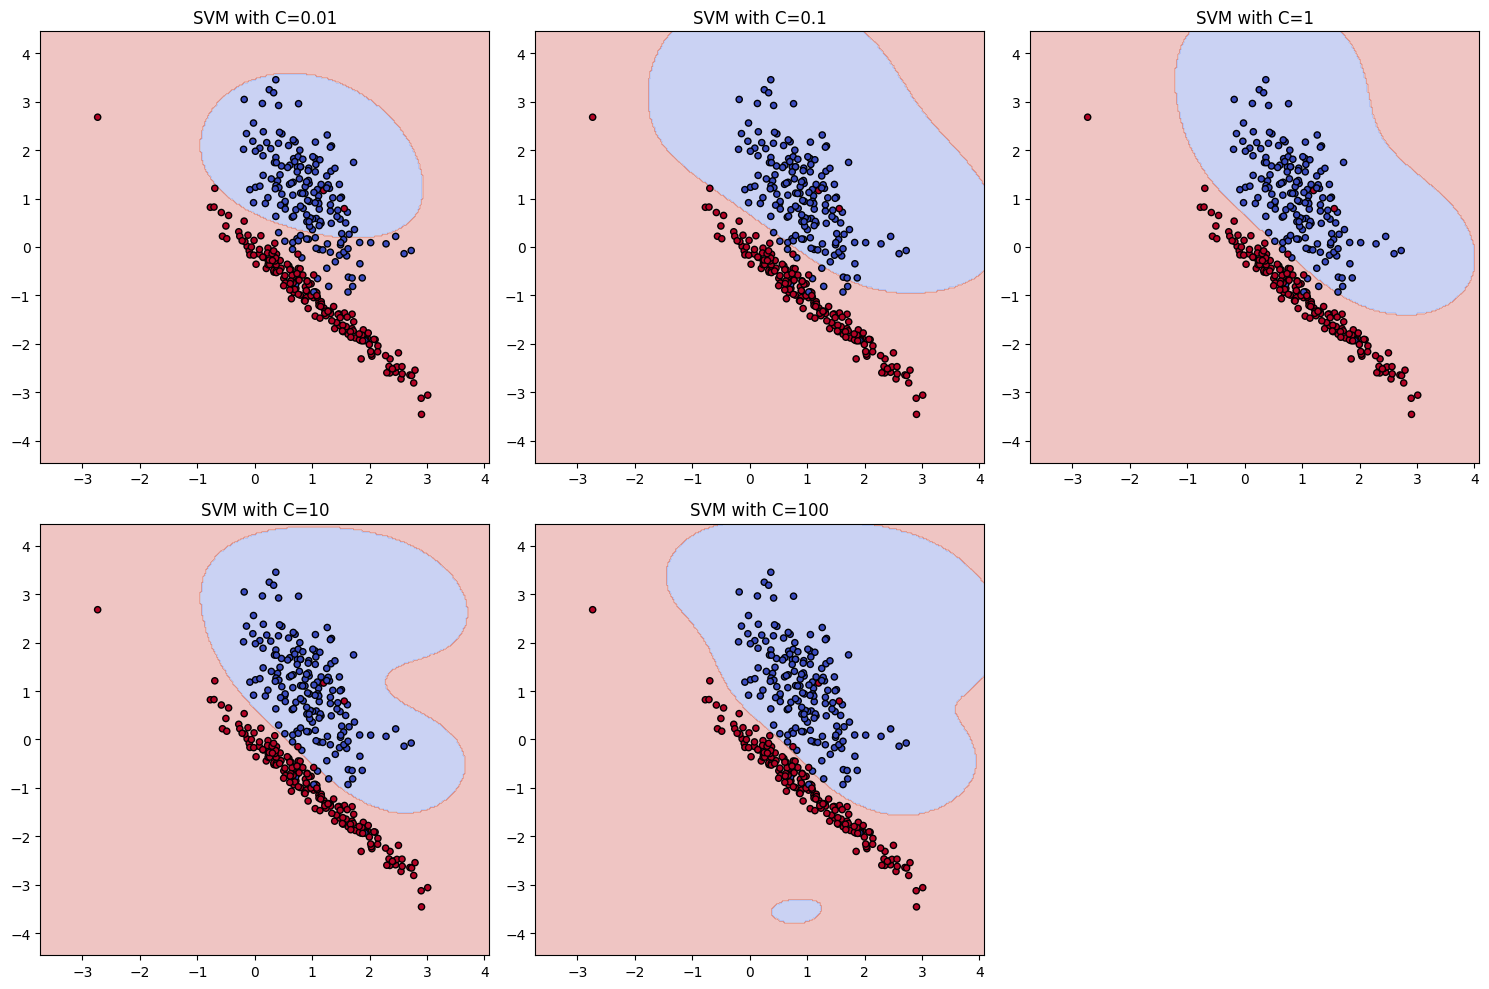

In [8]:
# 27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually
  
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2,random_state=1, n_clusters_per_class=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

C_values = [0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(15, 10))

for i, C in enumerate(C_values, 1):
    model = SVC(kernel="rbf", C=C)
    model.fit(X_train, y_train)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor="k", cmap=plt.cm.coolwarm)
    plt.title(f"SVM with C={C}")

plt.tight_layout()
plt.show()



In [9]:
# 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features.

from sklearn.naive_bayes import BernoulliNB

X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2,random_state=1, n_clusters_per_class=1)

# Convert features to binary (0/1) using a threshold
X = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

model = BernoulliNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0])

In [10]:
# 29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.

from sklearn.preprocessing import MinMaxScaler

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X, y = df.iloc[:, :-1], df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Model without Scaling ----
model_unscaled = SVC(kernel='rbf', C=1, gamma='scale')
model_unscaled.fit(X_train, y_train)
y_pred_unscaled = model_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# ---- Model with Scaling ----
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = SVC(kernel='rbf', C=1, gamma='scale')
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy without Scaling:", acc_unscaled)
print("Accuracy with Scaling:", acc_scaled)


Accuracy without Scaling: 0.8055555555555556
Accuracy with Scaling: 1.0


In [11]:
# 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing.

# Note: Gaussian Naive Bayes doesn't use Laplace Smoothing instead it uses Var Smoothing

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X, y = df.iloc[:, :-1], df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# GaussianNB with default smoothing
model_default = GaussianNB(var_smoothing=1e-9)
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)

# GaussianNB with higher "Laplace-like" smoothing
model_smooth = GaussianNB(var_smoothing=1) 
model_smooth.fit(X_train, y_train)
y_pred_smooth = model_smooth.predict(X_test)

print("Accuracy (default smoothing):", accuracy_score(y_test, y_pred_default))
print("Accuracy (high smoothing):", accuracy_score(y_test, y_pred_smooth))

print("\nPredictions with default smoothing:\n", y_pred_default[:15])
print("\nPredictions with high smoothing:\n", y_pred_smooth[:15])


Accuracy (default smoothing): 1.0
Accuracy (high smoothing): 0.7222222222222222

Predictions with default smoothing:
 [0 0 2 0 1 0 1 2 1 2 0 2 0 1 0]

Predictions with high smoothing:
 [1 0 1 0 1 0 1 1 1 1 1 1 0 1 0]


In [57]:
# 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)


from sklearn.model_selection import GridSearchCV

data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],        # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001], # Kernel coefficient
    'kernel': ['linear', 'rbf', 'poly']  # Types of kernels
}

grid = GridSearchCV(svm, param_grid, refit=True, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Predictions with best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Test Accuracy: 0.9722222222222222


In [12]:
# 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy.

from sklearn.metrics import classification_report

X, y = make_classification(n_samples=2000, n_features=10, n_informative=5, n_redundant=2,weights=[0.9, 0.1],  random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Model without class_weight
model1 = SVC(kernel='rbf', random_state=42)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

print("Without class_weight:")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

# Model with class_weight='balanced'
model2 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("\nWith class_weight='balanced':")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Without class_weight:
Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       538
           1       0.95      0.63      0.76        62

    accuracy                           0.96       600
   macro avg       0.96      0.81      0.87       600
weighted avg       0.96      0.96      0.95       600


With class_weight='balanced':
Accuracy: 0.9083333333333333
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       538
           1       0.53      0.92      0.67        62

    accuracy                           0.91       600
   macro avg       0.76      0.91      0.81       600
weighted avg       0.94      0.91      0.92       600



In [14]:
# 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.

from sklearn.feature_extraction.text import CountVectorizer

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

df["label"] = df["label"].map({"ham": 0, "spam": 1})

X, y = df["message"], df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert text to numeric features (Bag of Words)
vectorizer = CountVectorizer(stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naïve Bayes
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_test_vec)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.986244019138756

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1448
           1       0.97      0.92      0.95       224

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



In [15]:
# 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy.

import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X, y = df.iloc[:, :-1], df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm_model = SVC(kernel="rbf", C=1, gamma="scale")
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

SVM Accuracy: 0.6944444444444444
Naïve Bayes Accuracy: 0.9722222222222222


In [16]:
# 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results.

import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X, y = df.iloc[:, :-1], df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

nb_all = GaussianNB()
nb_all.fit(X_train, y_train)
y_pred_all = nb_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

selector = SelectKBest(score_func=chi2, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

nb_selected = GaussianNB()
nb_selected.fit(X_train_selected, y_train)
y_pred_selected = nb_selected.predict(X_test_selected)
acc_selected = accuracy_score(y_test, y_pred_selected)

print("Naïve Bayes Accuracy (All Features):", acc_all)
print("Naïve Bayes Accuracy (Selected Features):", acc_selected)


Naïve Bayes Accuracy (All Features): 0.9722222222222222
Naïve Bayes Accuracy (Selected Features): 0.9444444444444444


In [17]:
# 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy.

import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score

data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ovr_model = OneVsRestClassifier(SVC(kernel="linear"))
ovr_model.fit(X_train, y_train)
y_pred_ovr = ovr_model.predict(X_test)
acc_ovr = accuracy_score(y_test, y_pred_ovr)

ovo_model = OneVsOneClassifier(SVC(kernel="linear"))
ovo_model.fit(X_train, y_train)
y_pred_ovo = ovo_model.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

print("Accuracy with One-vs-Rest (OvR):", acc_ovr)
print("Accuracy with One-vs-One (OvO):", acc_ovo)

Accuracy with One-vs-Rest (OvR): 0.9444444444444444
Accuracy with One-vs-One (OvO): 0.9444444444444444


In [18]:
# 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Linear Kernel": SVC(kernel="linear"),
    "Polynomial Kernel": SVC(kernel="poly", degree=3),  # degree=3 default
    "RBF Kernel": SVC(kernel="rbf"),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")


Linear Kernel Accuracy: 0.9561
Polynomial Kernel Accuracy: 0.9211
RBF Kernel Accuracy: 0.9298


In [19]:
# 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy.

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = SVC(kernel="linear")

accuracies = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print("Accuracy for each fold:", np.round(accuracies, 4))
print("Average Accuracy:", np.mean(accuracies).round(4))


Accuracy for each fold: [0.9474 0.9298 0.9561 0.9386 0.9646]
Average Accuracy: 0.9473


In [20]:
# 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

priors_list = [
    None,                  
    [0.5, 0.5],             # Equal priors
    [0.7, 0.3],             # Biased towards class 0
    [0.3, 0.7]              # Biased towards class 1
]

for priors in priors_list:
    model = GaussianNB(priors=priors)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Priors = {priors}, Accuracy = {acc:.4f}")


Priors = None, Accuracy = 0.9386
Priors = [0.5, 0.5], Accuracy = 0.9386
Priors = [0.7, 0.3], Accuracy = 0.9298
Priors = [0.3, 0.7], Accuracy = 0.9474


In [21]:
# 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm_all = SVC(kernel="linear").fit(X_train, y_train)
print("All features:", accuracy_score(y_test, svm_all.predict(X_test)))

selector = RFE(SVC(kernel="linear"), n_features_to_select=5).fit(X_train, y_train)
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

svm_rfe = SVC(kernel="linear").fit(X_train_rfe, y_train)
print("RFE selected features:", accuracy_score(y_test, svm_rfe.predict(X_test_rfe)))


All features: 0.9444444444444444
RFE selected features: 0.9166666666666666


In [22]:
# 41.  Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_pred = SVC(kernel="linear").fit(X_train, y_train).predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))


Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1-Score: 0.9659863945578231


In [23]:
# 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = GaussianNB().fit(X_train, y_train).predict_proba(X_test)
print("Log Loss:", log_loss(y_test, y_prob))

Log Loss: 0.37125554670251204


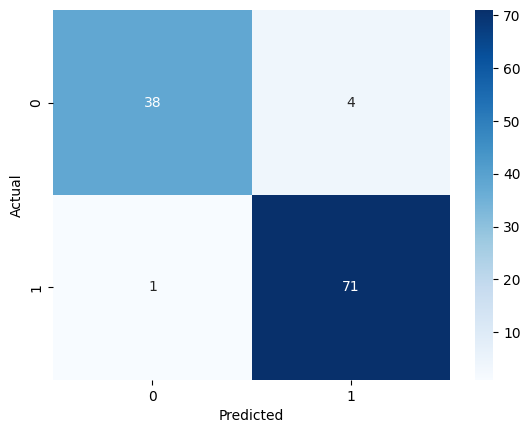

In [24]:
# 43.  Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_pred = SVC(kernel="linear").fit(X_train, y_train).predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [25]:
# 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = SVR(kernel="rbf").fit(X_train, y_train).predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


Mean Absolute Error: 0.8599506583445775


In [26]:
# 45.  Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = GaussianNB().fit(X_train, y_train).predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


ROC-AUC Score: 0.9877645502645502


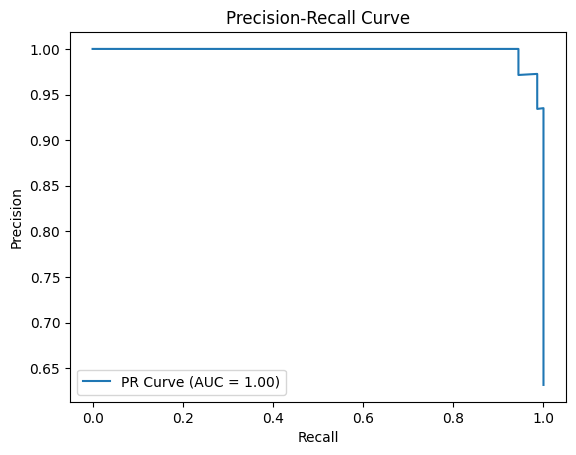

In [27]:
# 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()